In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage


In [8]:
data = pd.read_csv('gaia_stars_with_phases.csv')
print(f"Dataset contains {len(data)} stars")
print("\nAvailable columns:", data.columns.tolist())

Dataset contains 70118 stars

Available columns: ['ra', 'dec', 'parallax', 'parallax_error', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'bp_rp', 'radial_velocity', 'ruwe', 'teff_gspphot', 'phot_variable_flag', 'distance_pc', 'abs_mag', 'phase', 'cluster']


In [9]:
# Prepare feature matrix
features = data[['bp_rp', 'abs_mag', 'teff_gspphot']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

1. Optimal Cluster count(Silhouette)

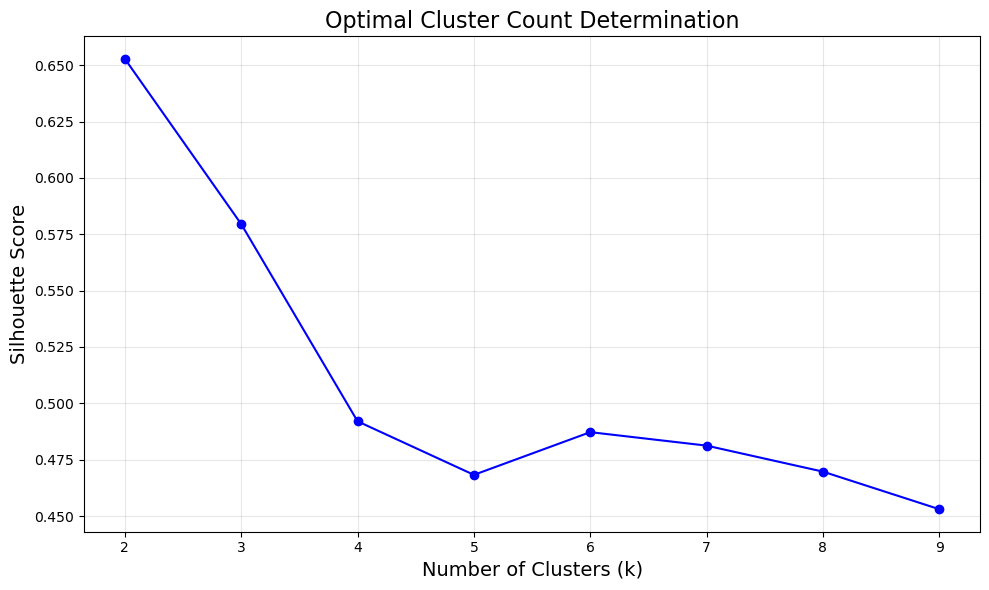

Optimal cluster count: 2


In [4]:
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (k)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.title('Optimal Cluster Count Determination', fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal cluster count: {k_range[np.argmax(silhouette_scores)]}")

Guassian Mixture Model(GMM)

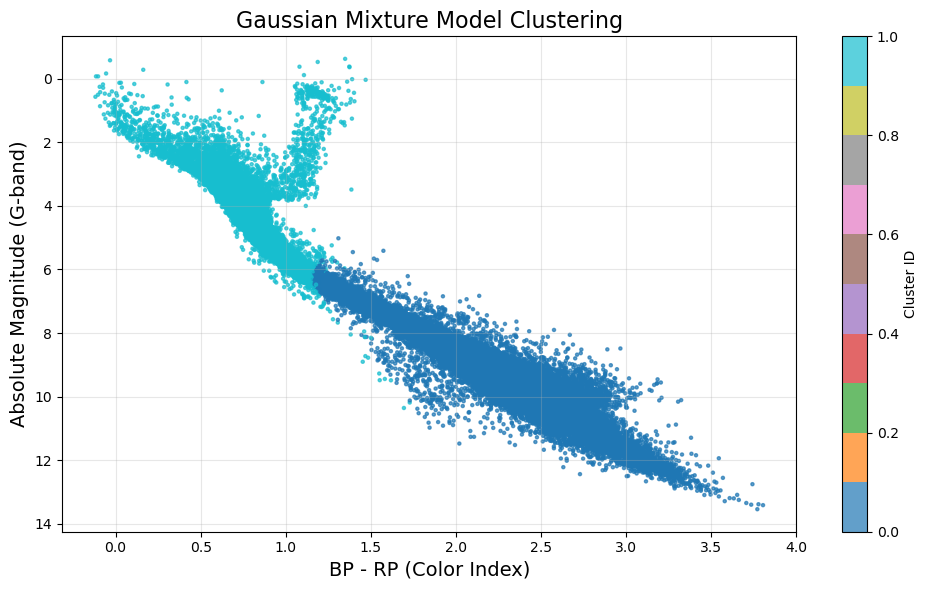


GMM Cluster Characteristics:


,gmm_cluster,bp_rp,abs_mag,teff_gspphot,phase
0,0,2.114170,8.864128,3819.312475,Main Sequence
1,1,0.843892,4.578499,5707.981478,Main Sequence


In [10]:
n_components = k_range[np.argmax(silhouette_scores)]
gmm = GaussianMixture(n_components=n_components, random_state=42)
data['gmm_cluster'] = gmm.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    data['bp_rp'], 
    data['abs_mag'], 
    c=data['gmm_cluster'], 
    s=5, 
    alpha=0.7,
    cmap='tab10'
)
plt.gca().invert_yaxis()
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.title('Gaussian Mixture Model Clustering', fontsize=16)
plt.colorbar(sc, label='Cluster ID')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Analyze cluster properties
gmm_cluster_stats = data.groupby('gmm_cluster').agg({
    'bp_rp': 'mean',
    'abs_mag': 'mean',
    'teff_gspphot': 'mean',
    'phase': lambda x: x.value_counts().index[0]  # Most common phase
}).reset_index()
print("\nGMM Cluster Characteristics:")
display(gmm_cluster_stats)

--- 
# ☢️☣️ KERNEL CRASH⛔️

Hierarchical Clusterring

In [1]:
# Compute linkage matrix
Z = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.xlabel('Sample Index or Cluster Size', fontsize=14)
plt.ylabel('Distance', fontsize=14)
plt.title('Hierarchical Clustering Dendrogram', fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'linkage' is not defined

In [ ]:
# Fit Agglomerative Clustering
agg_cluster = AgglomerativeClustering(n_clusters=n_components, linkage='ward')
data['hierarchical_cluster'] = agg_cluster.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    data['bp_rp'], 
    data['abs_mag'], 
    c=data['hierarchical_cluster'], 
    s=5, 
    alpha=0.7,
    cmap='tab10'
)
plt.gca().invert_yaxis()
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.title('Hierarchical Clustering', fontsize=16)
plt.colorbar(sc, label='Cluster ID')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

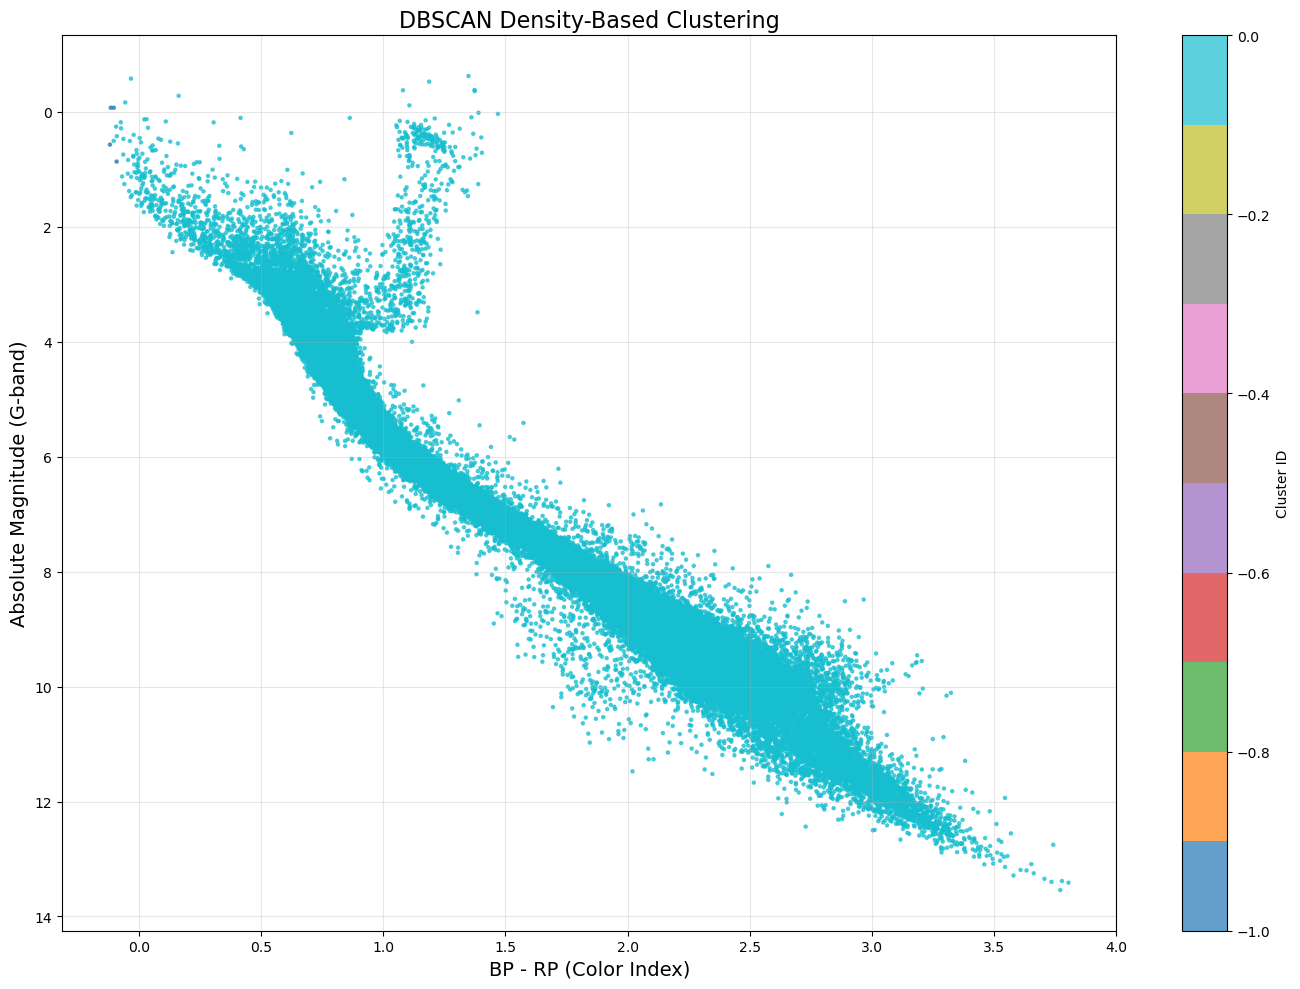


DBSCAN Cluster Distribution:
dbscan_cluster
 0    70114
-1        4
Name: count, dtype: int64


In [12]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
data['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(14, 10))
sc = plt.scatter(
    data['bp_rp'], 
    data['abs_mag'], 
    c=data['dbscan_cluster'], 
    s=5, 
    alpha=0.7,
    cmap='tab10'
)
plt.gca().invert_yaxis()
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.title('DBSCAN Density-Based Clustering', fontsize=16)
plt.colorbar(sc, label='Cluster ID')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Analyze cluster distribution
dbscan_counts = data['dbscan_cluster'].value_counts()
print("\nDBSCAN Cluster Distribution:")
print(dbscan_counts)

Clustering comparison n validation

In [17]:
# Compare clustering methods
methods = ['phase', 'cluster', 'gmm_cluster', 'dbscan_cluster']
comparison = data[methods].copy()

# Map cluster IDs to consistent phase names
phase_mapping = {
    0: 'Main Sequence',
    1: 'Giants',
    2: 'White Dwarfs',
    3: 'Subgiants',
    4: 'Supergiants'
}

for method in methods[1:]:
    # Get most common phase for each cluster
    cluster_map = {}
    for cluster_id in comparison[method].unique():
        cluster_data = comparison[comparison[method] == cluster_id]
        most_common_phase = cluster_data['phase'].value_counts().index[0]
        cluster_map[cluster_id] = most_common_phase
    
    # Map cluster IDs to phase names
    comparison[f'{method}_phase'] = comparison[method].map(cluster_map)

# Calculate agreement with rule-based phases
for method in methods[1:]:
    agreement = np.mean(comparison['phase'] == comparison[f'{method}_phase'])
    print(f"Agreement between rule-based and {method}: {agreement:.2%}")


Agreement between rule-based and cluster: 89.55%
Agreement between rule-based and gmm_cluster: 82.78%
Agreement between rule-based and dbscan_cluster: 82.79%


In [20]:
# Fix 1: Add required columns to comparison DataFrame
comparison = data[methods + ['bp_rp', 'abs_mag']].copy()  # Add plotting columns

# Fix 2: Update methods list for visualization
plot_methods = ['phase', 'gmm_cluster_phase', 'hierarchical_cluster_phase', 'dbscan_cluster_phase']

# Fix 3: Use consistent naming in visualization loop
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
titles = ['Rule-Based Classification', 'GMM Classification', 'Hierarchical Classification', 'DBSCAN Classification']

for i, (ax, method) in enumerate(zip(axes.flatten(), plot_methods)):
    for phase in comparison['phase'].unique():
        phase_data = comparison[comparison[method] == phase]
        ax.scatter(
            phase_data['bp_rp'], 
            phase_data['abs_mag'], 
            s=5, 
            alpha=0.7,
            label=phase
        )
    
    ax.invert_yaxis()
    ax.set_title(titles[i], fontsize=14)  # Use index for title
    ax.set_xlabel('BP - RP (Color Index)')
    ax.set_ylabel('Absolute Magnitude (G-band)')
    ax.grid(alpha=0.3)
    
    if i == 0:
        ax.legend(markerscale=3)

plt.tight_layout()
plt.show()

KeyError: "['gmm_cluster_phase', 'dbscan_cluster_phase'] not in index"

In [15]:
data['final_phase'] = data['cluster_phase']

# Main Sequence Analysis
main_sequence = data[data['final_phase'] == 'Main Sequence']
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='bp_rp', 
    y='abs_mag', 
    hue='teff_gspphot', 
    data=main_sequence, 
    palette='viridis_r',
    alpha=0.7
)
plt.gca().invert_yaxis()
plt.title('Main Sequence Stars', fontsize=16)
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


KeyError: 'cluster_phase'